<a href="https://colab.research.google.com/github/Suwaathmi/Customer-Segmentation-Using-Clustering/blob/main/ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install libraries (only needed once)
!pip install matplotlib seaborn scikit-learn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage


In [3]:
# Load dataset
df = pd.read_csv("Mall_Customers.csv")

# Preview data
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
# Select relevant features
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


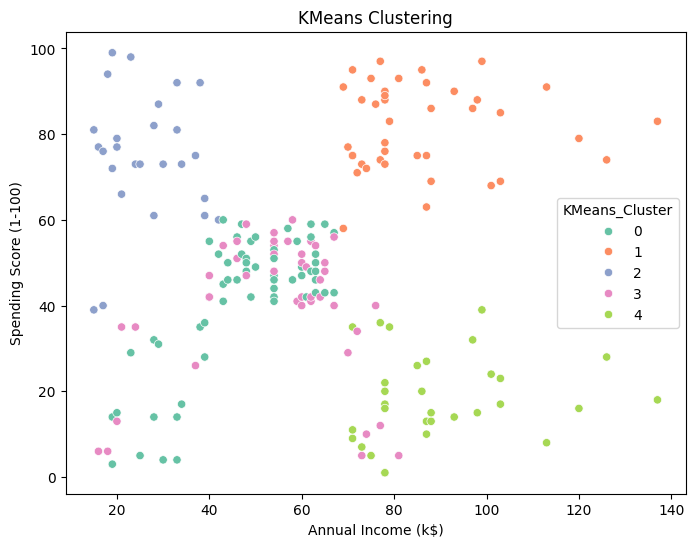

In [6]:
# Apply KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Visualize clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'],
                hue=df['KMeans_Cluster'], palette='Set2')
plt.title("KMeans Clustering")
plt.show()


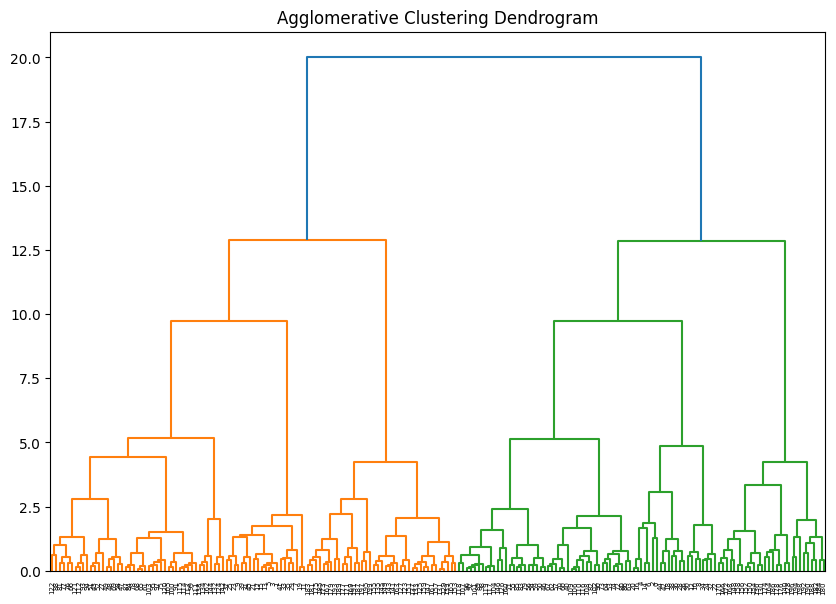

In [7]:
# Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['Agg_Cluster'] = agg.fit_predict(X_scaled)

# Dendrogram
linked = linkage(X_scaled, 'ward')
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.title("Agglomerative Clustering Dendrogram")
plt.show()


In [8]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("KMeans Silhouette:", silhouette_score(X_scaled, df['KMeans_Cluster']))
print("Agglomerative Silhouette:", silhouette_score(X_scaled, df['Agg_Cluster']))

print("KMeans DB Index:", davies_bouldin_score(X_scaled, df['KMeans_Cluster']))
print("Agglomerative DB Index:", davies_bouldin_score(X_scaled, df['Agg_Cluster']))

print("KMeans CH Index:", calinski_harabasz_score(X_scaled, df['KMeans_Cluster']))
print("Agglomerative CH Index:", calinski_harabasz_score(X_scaled, df['Agg_Cluster']))


KMeans Silhouette: 0.40846873777345605
Agglomerative Silhouette: 0.39002826186267214
KMeans DB Index: 0.8889693268899006
Agglomerative DB Index: 0.9162886109753661
KMeans CH Index: 123.41870976849417
Agglomerative CH Index: 107.82656032570374
